# Importing the Libraries

In [81]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Downloading the dataset 

In [82]:

df = pd.read_csv("KmeanCluster.csv")
df_copy = df.copy()

In [83]:
df_copy.columns


Index(['ID', 'Hours Studied per day', 'Hours Slept per day'], dtype='str')

In [84]:
df_copy.head(5)

,ID,Hours Studied per day,Hours Slept per day
0,1,10.0,4.1
1,2,1.3,8.2
2,3,2.4,7.5
3,4,4.0,8.0
4,5,5.0,6.0


# Plotting the data for Visualization

C:\Users\ThinkPad\AppData\Local\Temp\ipykernel_23992\780473993.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


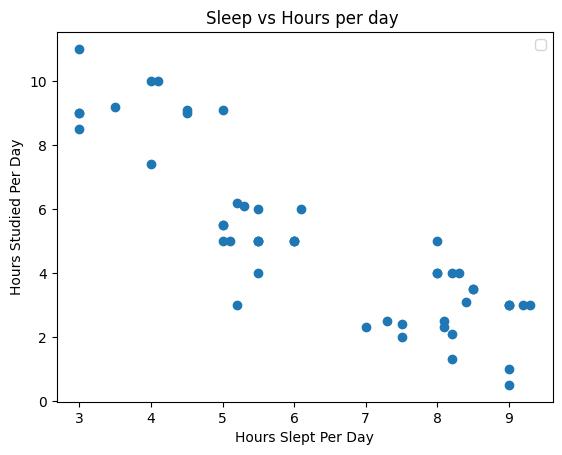

In [85]:
plt.ylabel("Hours Studied Per Day")
plt.xlabel("Hours Slept Per Day")
plt.scatter(df["Hours Slept per day"] ,df["Hours Studied per day"] )  #to draw a scatter plot
plt.title("Sleep vs Hours per day ")
plt.legend()
plt.show()


# K-Means Clustering


km.fit_predict = fit-> plots centroids and finds optimal centers for clusters 
predict-> Once the final centers are assigned, it assigns each data to a specific Cluster 

return km , y_predicted = return km-> returns the trained model
return y_predicted -> returns the list of labels  


In [86]:
def implement_KMC(df , K_Num):
    km= KMeans(n_clusters= K_Num) #object creation
    y_predicted = km.fit_predict(df[["Hours Slept per day" , "Hours Studied per day"]]) 
    return km , y_predicted

In [87]:
#running the method

k_num = 3
km, y_predicted = implement_KMC(df,k_num)
df["Group_cluster"]=y_predicted
df.head(10)


,ID,Hours Studied per day,Hours Slept per day,Group_cluster
0,1,10.0,4.1,1
1,2,1.3,8.2,2
2,3,2.4,7.5,2
3,4,4.0,8.0,0
4,5,5.0,6.0,0
5,6,5.0,5.5,1
6,7,5.0,6.0,0
7,8,3.0,5.2,2
8,9,2.0,7.5,2
9,10,6.0,6.1,1


Plotting the Cluster

In [88]:
#Plot the 3 clusters with different color from the prediciton value
def plot_cluster(km,df,cluster_num):  ##takes parameter: saved model, dataframe, number of clusters to visualize, note it has a limit of max 6 in this code
  
  color = ['green', 'red', 'blue', 'purple', 'black', 'yellow']
  for i in range(cluster_num):
    plt.scatter(df[df.Group_cluster==i]['Hours Slept per day'],df[df.Group_cluster==i]['Hours Studied per day'],color=color[i])
    plt.scatter(km.cluster_centers_[i,0],km.cluster_centers_[i,1],color=color[i],s=200,marker='X',label=f'centroid {i+1}')
    plt.xlabel('Hours Slept per day')
    plt.ylabel('Hours Studied per day')
    plt.legend()

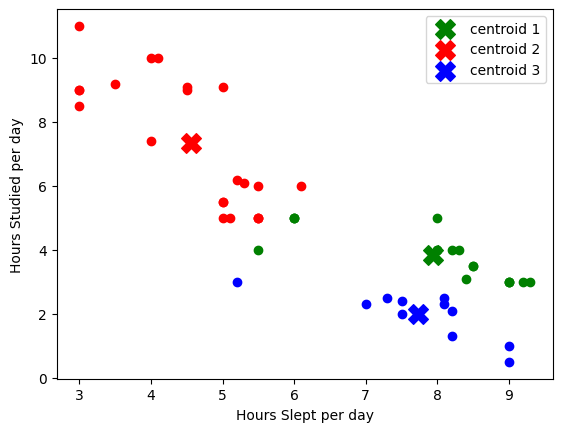

In [89]:
plot_cluster(km,df,k_num)

Labelling the clusters


In [90]:
label_map = {2: 'Chiller' , 0:'Balanced' ,1:'Nerd'}
df['Label'] = df['Group_cluster'].map(label_map)
display(df.head(10))

,ID,Hours Studied per day,Hours Slept per day,Group_cluster,Label
0,1,10.0,4.1,1,Nerd
1,2,1.3,8.2,2,Chiller
2,3,2.4,7.5,2,Chiller
3,4,4.0,8.0,0,Balanced
4,5,5.0,6.0,0,Balanced
5,6,5.0,5.5,1,Nerd
6,7,5.0,6.0,0,Balanced
7,8,3.0,5.2,2,Chiller
8,9,2.0,7.5,2,Chiller
9,10,6.0,6.1,1,Nerd


# K-Means Clustering using the IRIS dataset

n_init -> if the initial cluster is very bad , the structure of the clusters are going to be terrible. Thus n_init is the number of times the algorithm would run n times to put the initial cluster and choose the best initial cluster by measuring the WCSS

random_state -> it is a defined number for a the first random cluster, this basically means that each and every time we run the kmeans, the first random cluster will always remain the same

In [91]:
from sklearn.datasets import load_iris

iris = load_iris()

df = pd.DataFrame(iris.data , columns = iris.feature_names)
df['target'] = iris.target
df.head()
X = df[['sepal length (cm)', 'sepal width (cm)']]

def implement_KMC_iris(k_num):
    km = KMeans(n_clusters=k_num , random_state=42 ,n_init= 10)
    y_predicted = km.fit_predict(df[['sepal length (cm)', 'sepal width (cm)']])
    return km,y_predicted


Plotting Function for Iris

In [92]:
def plot_cluster1(km,df,cluster_num):  ##takes parameter: saved model, dataframe, number of clusters to visualize, note it has a limit of max 6 in this code
  if cluster_num>6:
    print("Cluster number should be less than 6, make your own plot method to fit more")
    return
  color = ['green', 'red', 'blue', 'purple', 'black', 'yellow']
  for i in range(cluster_num):
    plt.scatter(df[df.Group_clutter==i]['sepal length (cm)'],df[df.Group_clutter==i]['sepal width (cm)'],color=color[i])
    plt.scatter(km.cluster_centers_[i,0],km.cluster_centers_[i,1],color=color[i],s=200,marker='X',label=f'centroid {i+1}')
    plt.xlabel('sepal length (cm)')
    plt.ylabel('sepal width (cm)')
    plt.legend()

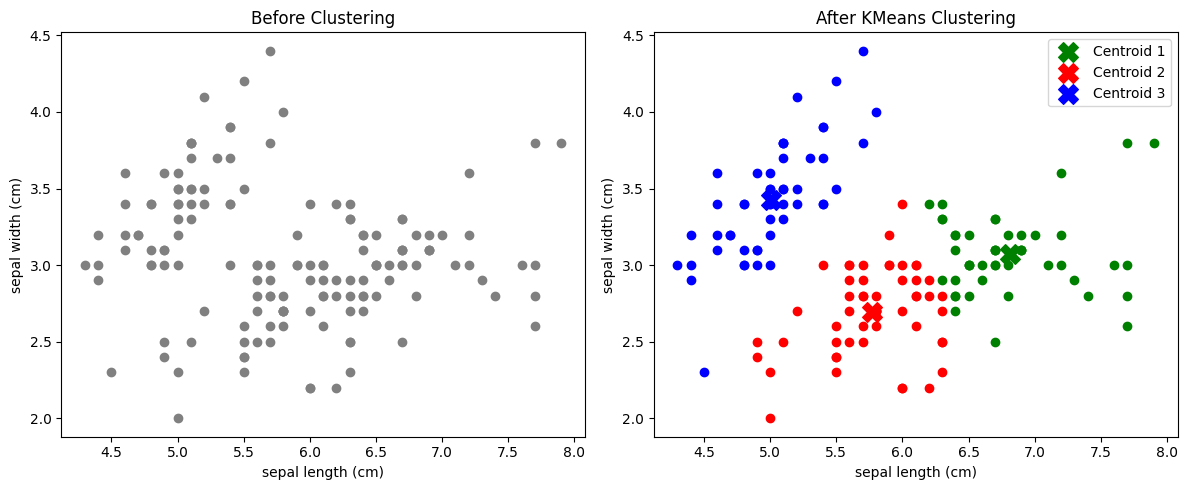

In [94]:
cluster = 3
km1, y_predicted = implement_KMC_iris(cluster)
df['Group_clutter'] = y_predicted

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Plot before clustering
axs[0].scatter(df['sepal length (cm)'], df['sepal width (cm)'], color='gray')
axs[0].set_title("Before Clustering")
axs[0].set_xlabel('sepal length (cm)')
axs[0].set_ylabel('sepal width (cm)')

# Plot after clustering
color = ['green', 'red', 'blue', 'purple', 'black', 'yellow']
for i in range(cluster):
    axs[1].scatter(df[df.Group_clutter == i]['sepal length (cm)'],
                   df[df.Group_clutter == i]['sepal width (cm)'],
                   color=color[i])
    axs[1].scatter(km1.cluster_centers_[i, 0],
                   km1.cluster_centers_[i, 1],
                   color=color[i], s=200, marker='X', label=f'Centroid {i+1}')

axs[1].set_title("After KMeans Clustering")
axs[1].set_xlabel('sepal length (cm)')
axs[1].set_ylabel('sepal width (cm)')
axs[1].legend()

plt.tight_layout()
plt.show()

In [95]:
print("Original Distribution of the Group\n")
df['target'].value_counts()

Original Distribution of the Group



target
0    50
1    50
2    50
Name: count, dtype: int64

In [96]:
print("Predicted Group Clutter Distribution:\n")
df['Group_clutter'].value_counts()

Predicted Group Clutter Distribution:



Group_clutter
1    53
2    50
0    47
Name: count, dtype: int64

# Elbow Method


km.fit(data) -> K-mean algorithm drops the centeroids ,calculates the distances and mathematically figures out where the clusters would be 

km.fit_predict(data) -> fits and then assigns a cluster value (0,1,2) to each of the cluster

km.intertia_ -> returns the WCSS score

In [97]:
k_range = range(1,10)
SSE = []
for k in k_range:
    km = KMeans(n_clusters=k)
    km.fit(df_copy[['Hours Slept per day','Hours Studied per day']])
    SSE.append(km.inertia_)
SSE

[536.8489999999999,
 186.5516083916084,
 58.95972084980238,
 54.890377415458936,
 42.35070833333334,
 29.065216450216447,
 24.995873015873013,
 22.11528571428572,
 17.77607359307359]

Plotting the K values vs SSE curve


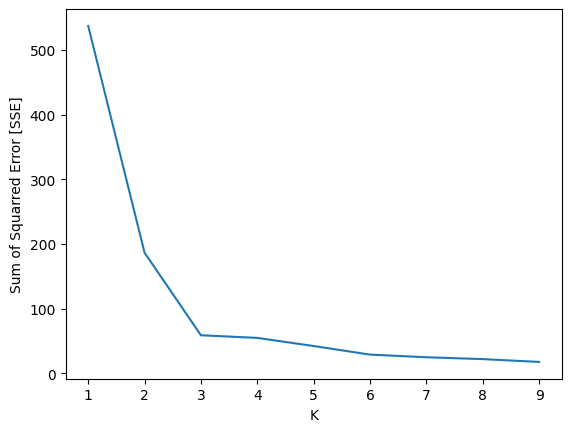

In [98]:
plt.xlabel("K")
plt.ylabel("Sum of Squarred Error [SSE]")
plt.plot(k_range,SSE)

Therefore , Elbow Point = 3